In [1]:
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
## make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.preprocessing import StandardScaler

def plot_results(y_to_train,
                 y_to_test, y_forecast,
                 plot_conf_int=True,
                 left_bound=None, right_bound=None):

    plt.plot(y_to_train, label='train')
    plt.plot(y_to_test, label='test')
    plt.plot(y_to_test.index, y_forecast, label='prediction')

    if plot_conf_int:
        plt.fill_between(y_to_test.index,
                         left_bound, right_bound,
                         alpha=0.23, color='grey',
                         label='intervals')
    plt.legend()
    plt.show()

## Prophet, SARIMAX, TBATS — модели для предсказания временных рядов

### 1. Задача

Рассмотрим [датасет](https://www.kaggle.com/c/demand-forecasting-kernels-only/overview) с kaggle с соревнования по прогнозированию спроса на товары.

In [2]:
data = pd.read_csv('train.csv', parse_dates=['date'])
data.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
store, item = 1,1
data = data[(data['store'] == store) & (data['item'] == item)]
data = data.set_index('date')
data = data['sales']

In [4]:
data

date
2013-01-01    13
2013-01-02    11
2013-01-03    14
2013-01-04    13
2013-01-05    10
              ..
2017-12-27    14
2017-12-28    19
2017-12-29    15
2017-12-30    27
2017-12-31    23
Name: sales, Length: 1826, dtype: int64

### 2. Данные
Разделим данные на train и test. test — данные за последний год.

In [5]:
test_size = 365
data_train = data.iloc[: -test_size]
data_test  = data.iloc[-test_size:]

Визуализируем данные.

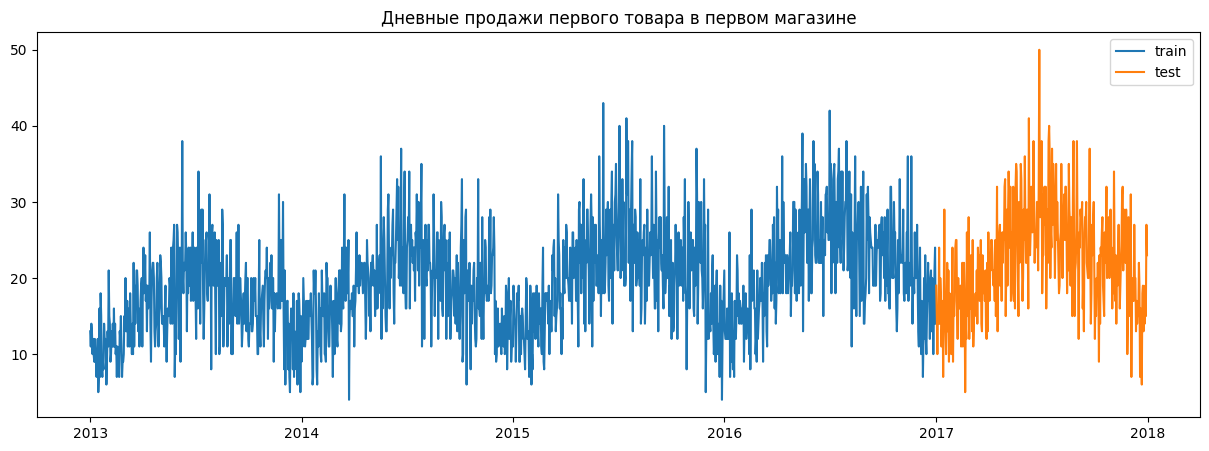

In [6]:
plt.figure(figsize=(15, 5))

plt.title('Дневные продажи первого товара в первом магазине')

plt.plot(data_train, label='train')
plt.plot(data_test, label='test')
plt.legend()

Некоторая недельная сезонность есть.

### 3. Метрики
Зададим метрики качества моделей: MSE, MAE, MAPE. Зададим функцию, которая будет вычислять метрики качества моделей и записывать их в таблицу.


- MAPE (Mean Absolute Percentage Error) поможет оценить, насколько близки прогнозы к фактическим значениям в процентном соотношении.
- 	MSE (Mean Squared Error) — для измерения среднеквадратичной ошибки между прогнозами и фактическими значениями. Это поможет понять среднюю ошибку прогноза в квадрате.
- 	MAE (Mean Absolute Error) — для оценки средней абсолютной ошибки между прогнозами и реальными значениями. Хорошо интерпретируется и проста в использовании.

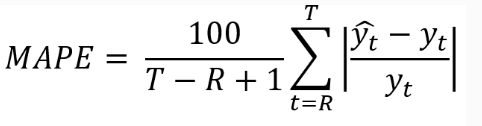

In [7]:
# MAPE
def mean_absolute_percentage_error(y_true, y_pred) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [8]:
def add_method_comparison(method: str, y_true, y_forecast, compare_table=None) -> pd.DataFrame:
    result_row = {
        'method': method,
        "MSE": mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE": mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE": mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast)
    }

    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
    return compare_table



### 4. Prophet

###4.1. Prophet

Prophet — модель для предсказания временных рядов, разработанная «Фейсбуком»*.

*Деятельность компании Meta Platforms Inc., которой принадлежит указаная соцсеть и сервис, признана экстремистской и запрещена на территории РФ.

In [9]:
prophet_train_df = pd.DataFrame(data_train)

prophet_train_df.columns = ['y']
prophet_train_df['ds'] = prophet_train_df.index

In [10]:
prophet_train_df

,y,ds
date,,
2013-01-01,13,2013-01-01
2013-01-02,11,2013-01-02
2013-01-03,14,2013-01-03
2013-01-04,13,2013-01-04
2013-01-05,10,2013-01-05
...,...,...
2016-12-27,10,2016-12-27
2016-12-28,16,2016-12-28
2016-12-29,21,2016-12-29


In [11]:
prophet_model = Prophet(interval_width=0.95)
prophet_model.fit(prophet_train_df)

future = prophet_model.make_future_dataframe(
    periods=test_size, include_history=False
)

y_prophet_forecast = prophet_model.predict(future)

19:20:47 - cmdstanpy - INFO - Chain [1] start processing
19:20:47 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
y_prophet_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,22.656367,12.522277,30.095876,22.656367,22.656367,-1.504747,-1.504747,-1.504747,3.723810,3.723810,3.723810,-5.228557,-5.228557,-5.228557,0.0,0.0,0.0,21.151621
1,2017-01-02,22.660412,5.209477,21.810116,22.660412,22.660412,-9.438711,-9.438711,-9.438711,-4.232954,-4.232954,-4.232954,-5.205757,-5.205757,-5.205757,0.0,0.0,0.0,13.221701
2,2017-01-03,22.664457,7.411559,24.727896,22.664455,22.664464,-6.836088,-6.836088,-6.836088,-1.636037,-1.636037,-1.636037,-5.200051,-5.200051,-5.200051,0.0,0.0,0.0,15.828369
3,2017-01-04,22.668502,7.725884,25.265949,22.668474,22.668540,-6.324862,-6.324862,-6.324862,-1.114510,-1.114510,-1.114510,-5.210352,-5.210352,-5.210352,0.0,0.0,0.0,16.343640
4,2017-01-05,22.672547,7.798237,25.211514,22.672497,22.672608,-5.942896,-5.942896,-5.942896,-0.707795,-0.707795,-0.707795,-5.235101,-5.235101,-5.235101,0.0,0.0,0.0,16.729651


Модель для каждой даты раскладывает своё предсказание на компоненты.

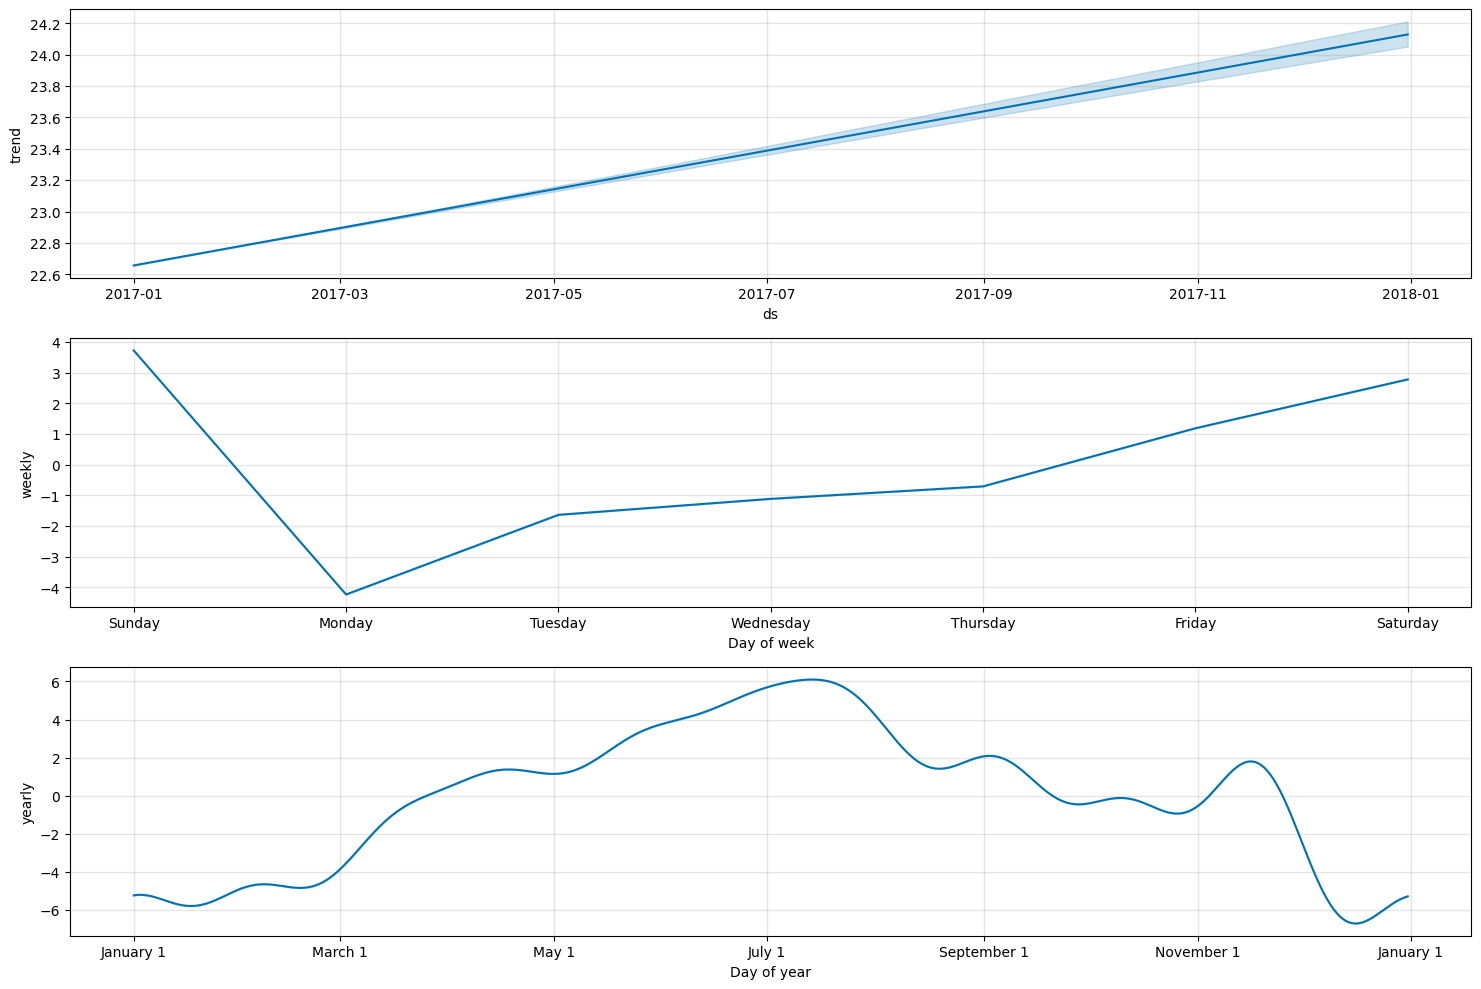

In [13]:
prophet_model.plot_components(y_prophet_forecast, figsize=(15, 10))
plt.show()

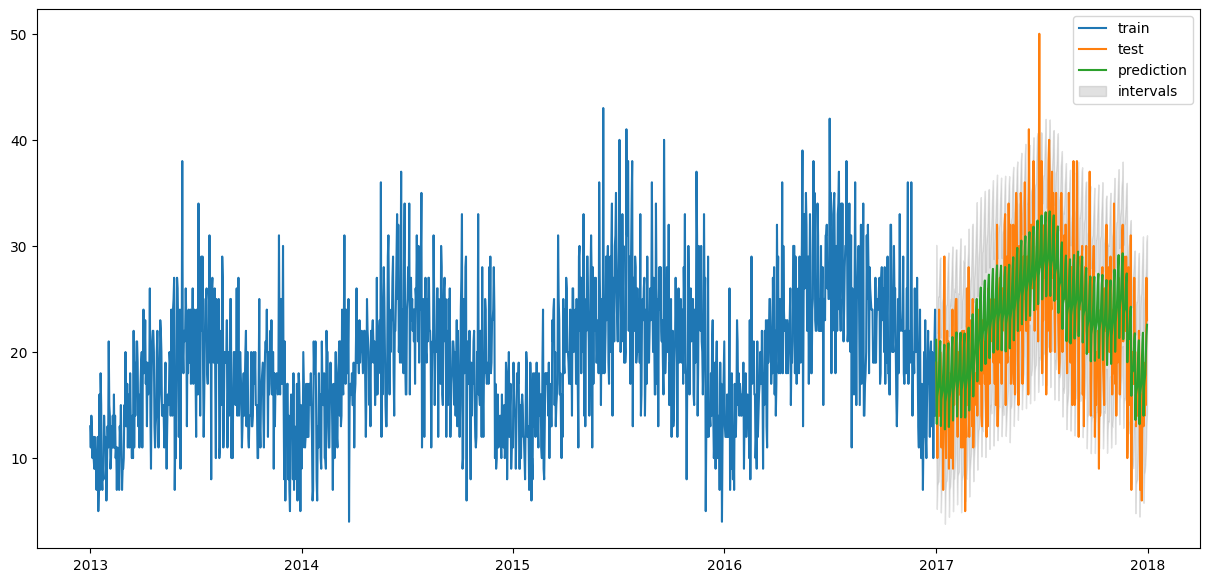

In [14]:
plot_results(data_train, data_test, y_prophet_forecast['yhat'], plot_conf_int=True,
             left_bound=y_prophet_forecast['yhat_lower'],
             right_bound=y_prophet_forecast['yhat_upper'])

In [15]:
compare_table = add_method_comparison('Prophet', data_test, y_prophet_forecast['yhat'])
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031


#### **Задание**
- Обучите модель Prophet с учётом праздников США — *Prophet + US holidays*.
- Преобразование Бокса — Кокса: обучите модель Prophet на преобразованном таргете — *Prophet*:
    - сделайте прямое преобразование над таргетом sps.boxcox(y);
    - потом сделайте обратное (нужно написать самостоятельно).

### 4.2. Prophet + US holidays

In [16]:
prophet_holidays_model = Prophet(interval_width=0.95)  # Создать модель
prophet_holidays_model.add_country_holidays(country_name="US") # Добавить праздники

In [17]:
prophet_holidays_model.fit(prophet_train_df)
future = prophet_holidays_model.make_future_dataframe(
    periods=test_size, include_history=False
)

y_prophet_holidays_forecast = prophet_holidays_model.predict(future)

19:20:49 - cmdstanpy - INFO - Chain [1] start processing
19:20:49 - cmdstanpy - INFO - Chain [1] done processing


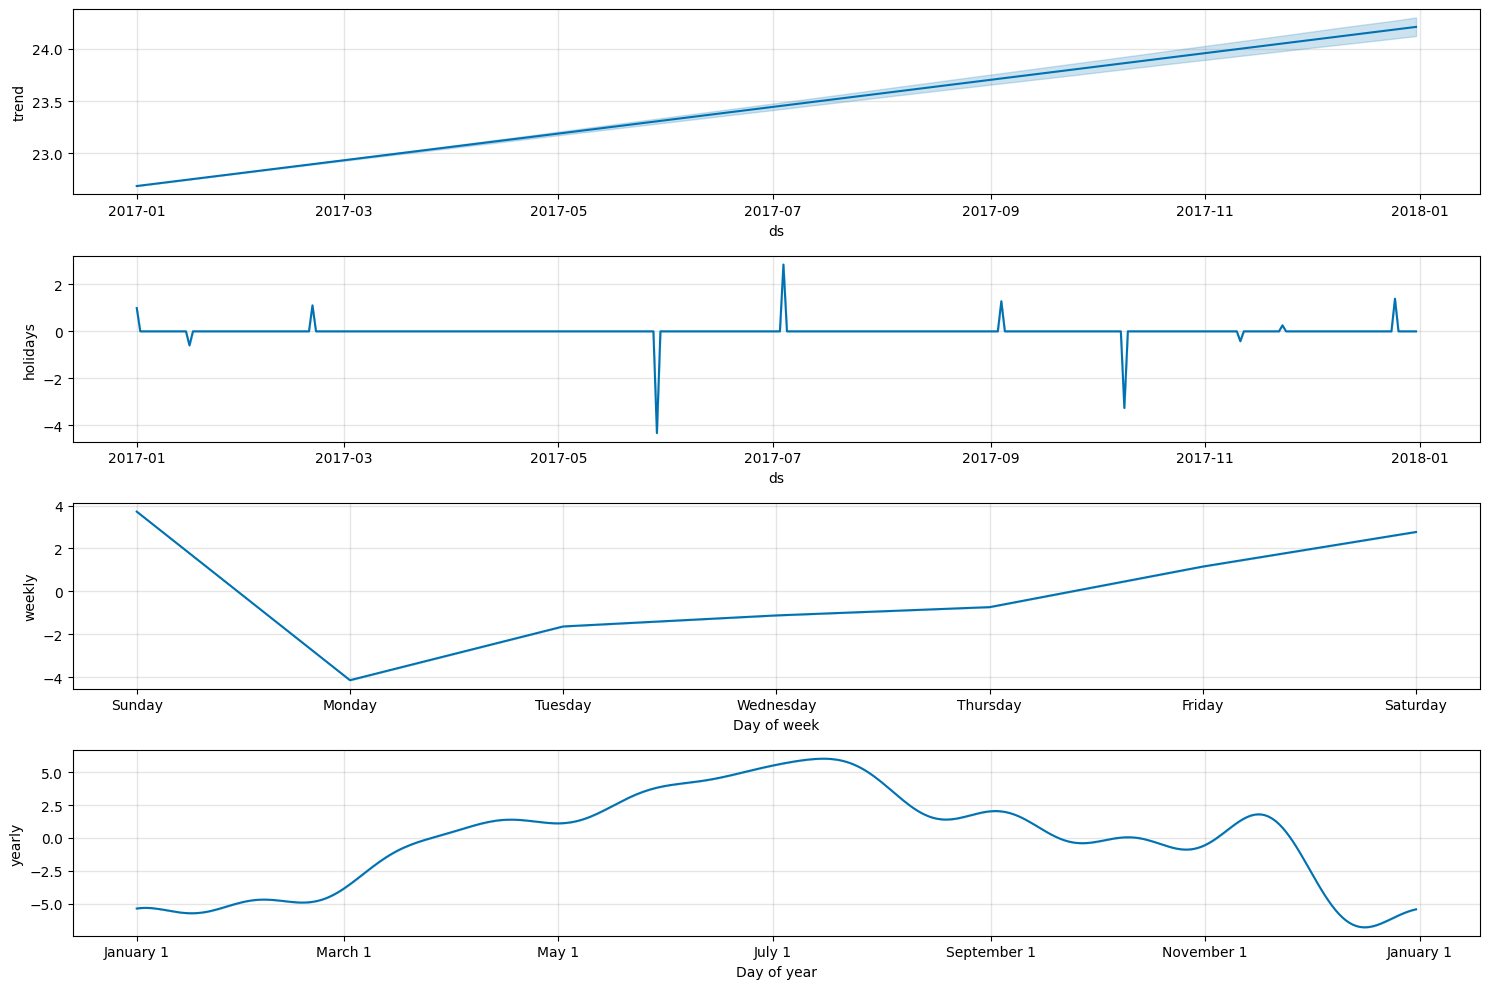

In [18]:
prophet_holidays_model.plot_components(y_prophet_holidays_forecast, figsize=(15, 10))
plt.show()

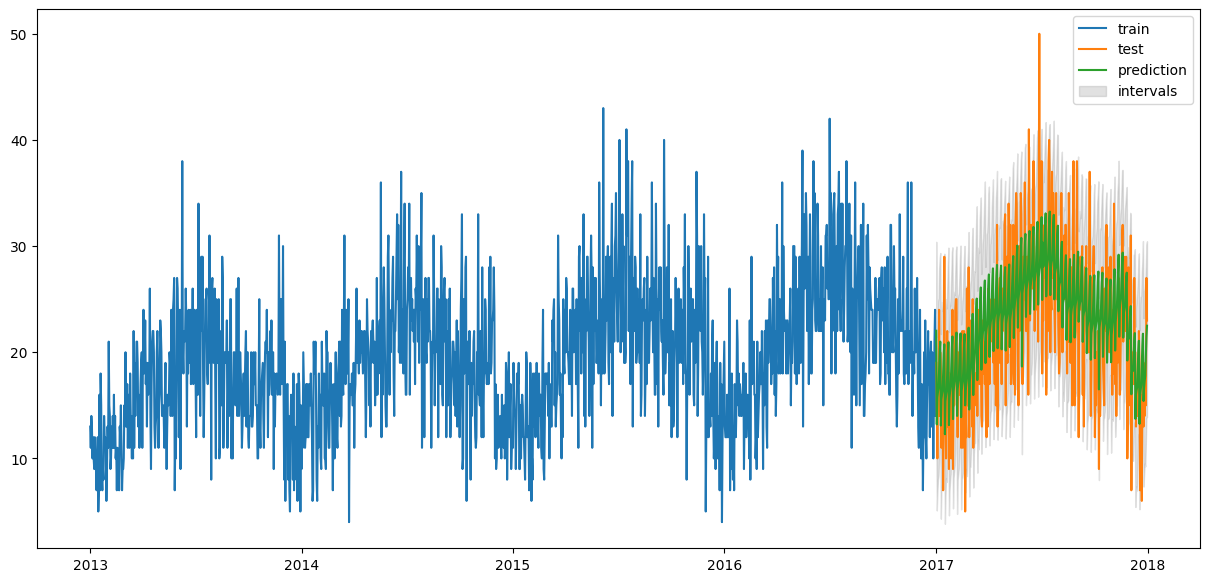

In [19]:
plot_results(data_train, data_test, y_prophet_holidays_forecast['yhat'], plot_conf_int=True,
             left_bound=y_prophet_holidays_forecast['yhat_lower'],
             right_bound=y_prophet_holidays_forecast['yhat_upper'])

In [20]:
compare_table = add_method_comparison('Prophet + US holiday', data_test, y_prophet_holidays_forecast['yhat'], compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342


### 4.3. Prophet. Преобразование Бокса — Кокса

In [21]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox

In [22]:
# Преобразовать данные с использованием оптимального лямбда
prophet_train_df['y'], lambda_value = boxcox(prophet_train_df['y'])
# Создать модель Prophet и добавить праздники (если нужно)
prophet_boxcox_model = Prophet(interval_width=0.95)
prophet_boxcox_model.add_country_holidays(country_name="US")  # Добавить праздники, если нужно

# Обучить модель
prophet_boxcox_model.fit(prophet_train_df)

# Сгенерировать прогнозы
future = prophet_boxcox_model.make_future_dataframe(periods=test_size, include_history=False)

prophet_boxcox_forecast = prophet_boxcox_model.predict(future)

# Обратное преобразование прогнозов
prophet_boxcox_forecast['yhat'] = inv_boxcox(prophet_boxcox_forecast['yhat'], lambda_value)
prophet_boxcox_forecast['yhat_lower'] = inv_boxcox(prophet_boxcox_forecast['yhat_lower'], lambda_value)
prophet_boxcox_forecast['yhat_upper'] = inv_boxcox(prophet_boxcox_forecast['yhat_upper'], lambda_value)

19:20:50 - cmdstanpy - INFO - Chain [1] start processing
19:20:51 - cmdstanpy - INFO - Chain [1] done processing


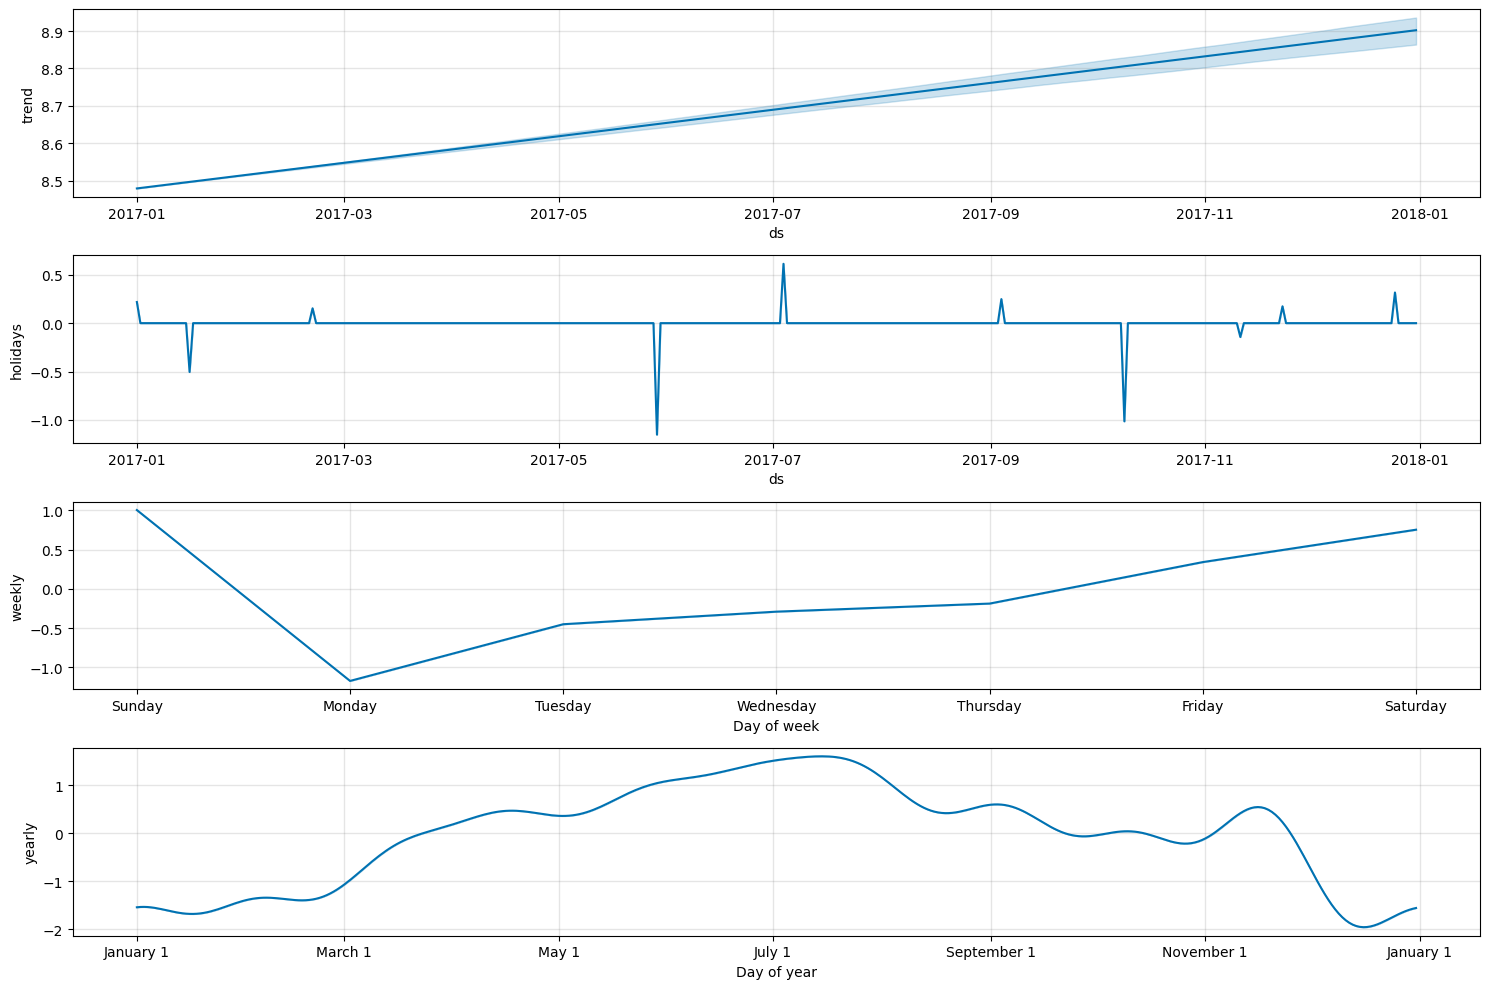

In [23]:
prophet_boxcox_model.plot_components(prophet_boxcox_forecast, figsize=(15, 10))
plt.show()

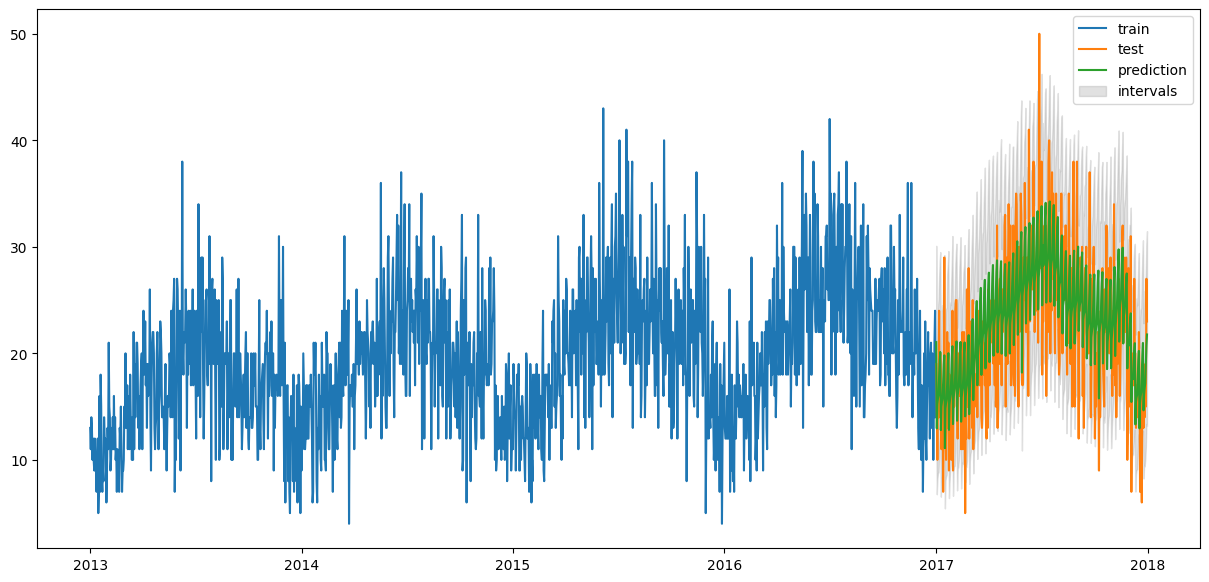

In [24]:
plot_results(data_train, data_test, prophet_boxcox_forecast['yhat'], plot_conf_int=True,
             left_bound=prophet_boxcox_forecast['yhat_lower'],
             right_bound=prophet_boxcox_forecast['yhat_upper'])

In [25]:
compare_table = add_method_comparison('Prophet boxcox', data_test, prophet_boxcox_forecast['yhat'], compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760


### 5. AutoARIMA [without exog]

### 5.1. AutoARIMA [without exog]

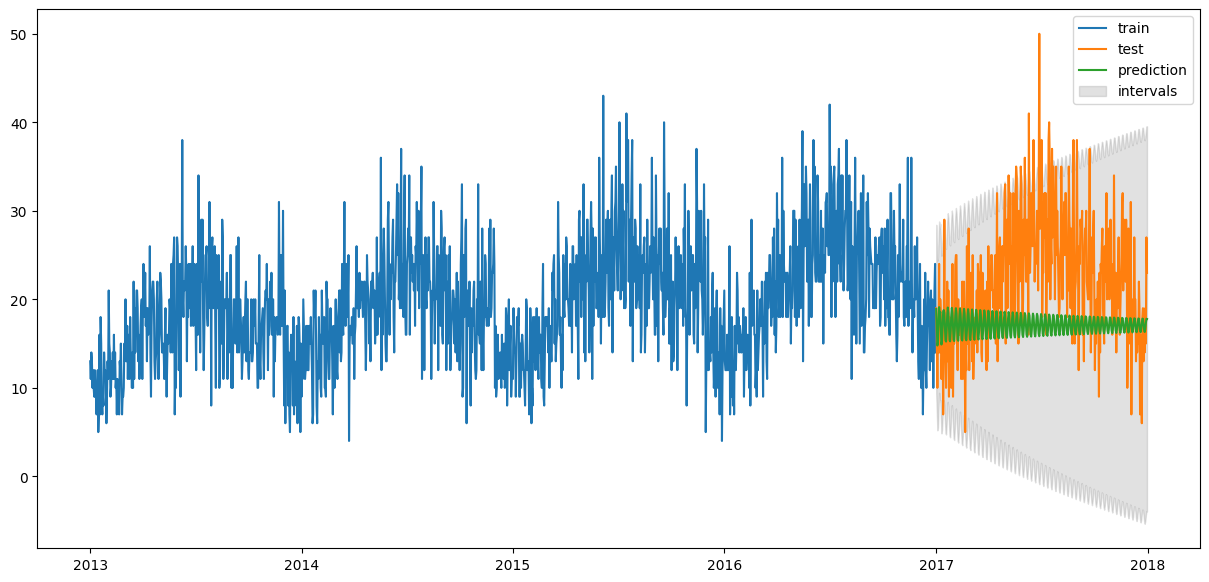

In [26]:
arima_model = auto_arima(data_train, seasonal=True, m = 7)

y_arima_forecast, conf_int = arima_model.predict(n_periods=test_size, return_conf_int=True, alpha=0.05)

plot_results(data_train, data_test, y_arima_forecast, plot_conf_int=True,
             left_bound=conf_int.T[0],
             right_bound=conf_int.T[1])

In [27]:
compare_table = add_method_comparison('Auto arima model', data_test, y_arima_forecast, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760
3,Auto arima model,71.311533,6.669087,28.959919


### 5.2. AutoARIMA exog

In [28]:
# Создание экзогенных переменных
exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

# Недельная сезонность
exog['sin7'] = np.sin(2 * np.pi * exog.index.dayofweek / 7)
exog['cos7'] = np.cos(2 * np.pi * exog.index.dayofweek / 7)

# Ежемесячная сезонность
exog['sin30'] = np.sin(2 * np.pi * exog.index.day / 30)
exog['cos30'] = np.cos(2 * np.pi * exog.index.day / 30)

# Добавление дополнительных экзогенных переменных
exog['weekday'] = exog.index.dayofweek

# Преобразование экзогенных переменных
scaler = StandardScaler()
exog[['sin365', 'cos365', 'sin7', 'cos7', 'sin30', 'cos30']] = scaler.fit_transform(exog[['sin365', 'cos365', 'sin7', 'cos7', 'sin30', 'cos30']])

# Разделение на тренировочный и тестовый наборы
exog_to_train = exog.iloc[:-test_size]
exog_to_test = exog.iloc[-test_size:]

# Обучение модели ARIMA с экзогенными переменными
arima_model_exog = auto_arima(data_train, exogenous=exog_to_train, seasonal=True, m=30)

# Прогнозирование с экзогенными переменными
y_arima_forecast_exog, conf_int = arima_model_exog.predict(n_periods=test_size, exogenous=exog_to_test, return_conf_int=True, alpha=0.05)


todo: используйте модель `auto_arima` с экзогенными переменными, которые созданы выше (их не надо менять).

Посчитайте метрики качества и добавьте их в датафрейм (сравнительную таблицу) с метриками по всем обученным до этого моделям.

In [29]:
# Добавление результатов в таблицу сравнения
compare_table = add_method_comparison("ARIMA с exog", data_test, y_arima_forecast_exog, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760
3,Auto arima model,71.311533,6.669087,28.959919
4,ARIMA с exog,74.399898,6.831763,29.443817


### 6. SARIMAX [without exog]

### 6.1. SARIMAX [without exog]

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# передаем параметры из прошлой модели
real_sarimax_model = SARIMAX(data_train, order=(3, 1, 5), seasonal_order=(0, 0, 2, 7),
    seasonal_periods=7,
    ).fit()


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasonal_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
forecast = real_sarimax_model.get_forecast(steps=len(data_test))
y_sarimax_real_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()


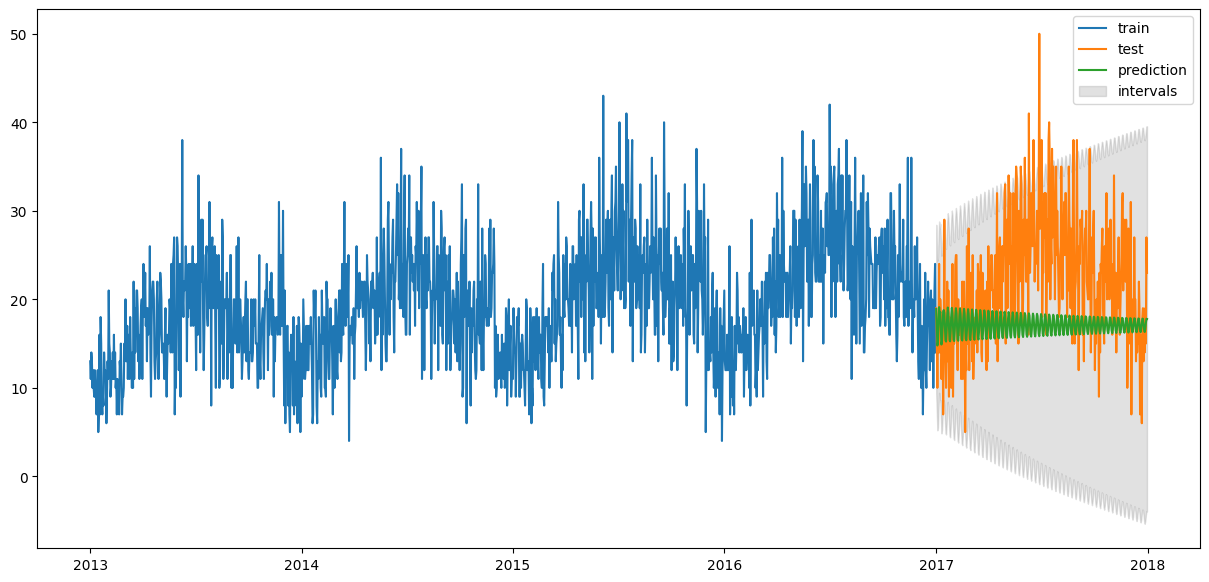

In [32]:
plot_results(data_train, data_test,
             y_sarimax_real_forecast, plot_conf_int=True,
             left_bound=conf_int['lower sales'], right_bound=conf_int['upper sales'])

In [33]:
compare_table = add_method_comparison('Original SARIMAX', data_test, y_sarimax_real_forecast, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760
3,Auto arima model,71.311533,6.669087,28.959919
4,ARIMA с exog,74.399898,6.831763,29.443817
5,Original SARIMAX,71.311533,6.669087,28.959919


### 6.2. SARIMAX with exog

In [34]:
# Создание экзогенных переменных
exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

# Недельная сезонность
exog['sin7'] = np.sin(2 * np.pi * exog.index.dayofweek / 7)
exog['cos7'] = np.cos(2 * np.pi * exog.index.dayofweek / 7)

# Ежемесячная сезонность
exog['sin30'] = np.sin(2 * np.pi * exog.index.day / 30)
exog['cos30'] = np.cos(2 * np.pi * exog.index.day / 30)

# Добавление дополнительных экзогенных переменных
exog['weekday'] = exog.index.dayofweek

# Преобразование экзогенных переменных
scaler = StandardScaler()
exog[['sin365', 'cos365', 'sin7', 'cos7', 'sin30', 'cos30']] = scaler.fit_transform(exog[['sin365', 'cos365', 'sin7', 'cos7', 'sin30', 'cos30']])

exog = exog.drop(columns=['date'])

# Разделение на тренировочный и тестовый наборы
exog_to_train = exog.iloc[:-test_size]
exog_to_test = exog.iloc[-test_size:]

# Обучение модели SARIMAX с экзогенными переменными
sarimax_model_exog = SARIMAX(data_train, exog=exog_to_train, order=(3, 1, 5), seasonal_order=(0, 0, 2, 7),
                         seasonal_periods=7).fit()

# Прогнозирование с экзогенными переменными
forecast = sarimax_model_exog.get_forecast(steps=len(data_test), exog=exog_to_test)
y_sarimax_forecast_exog = forecast.predicted_mean
conf_int = forecast.conf_int()

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasonal_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Use

todo: используйте модель `SARIMAX` с экзогенными переменными, которые созданы выше (их не надо менять), для улучшения предсказаний.

In [35]:
compare_table = add_method_comparison('SARIMAX с exog', data_test, y_sarimax_forecast_exog, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760
3,Auto arima model,71.311533,6.669087,28.959919
4,ARIMA с exog,74.399898,6.831763,29.443817
5,Original SARIMAX,71.311533,6.669087,28.959919
6,SARIMAX с exog,24.477670,3.896864,19.522031


### 7. TBATS

Модель учитывает несколько сезонностей, но не может принимать экзогенные признаки.

In [36]:
tbats_estimator = TBATS(seasonal_periods=(7,180))
model = tbats_estimator.fit(data_train)

In [37]:
print(model.summary())

Use Box-Cox: False
Use trend: False
Use damped trend: False
Seasonal periods: [  7. 180.]
Seasonal harmonics [3 3]
ARMA errors (p, q): (0, 0)
Smoothing (Alpha): 0.099254
Seasonal Parameters (Gamma): [ 0.00073055  0.00126939 -0.00168362 -0.00071569]
AR coefficients []
MA coefficients []
Seed vector [11.64783078 -2.63361686 -0.19728629  1.19371923 -0.73577877  1.77368199
  0.93247816  0.28014787 -0.22456824 -0.7175311  -0.93148604 -0.02311377
  0.1540708 ]

AIC 15098.062904


In [38]:
tbats_forecast, confidence_info = model.forecast(steps=365, confidence_level=0.95)

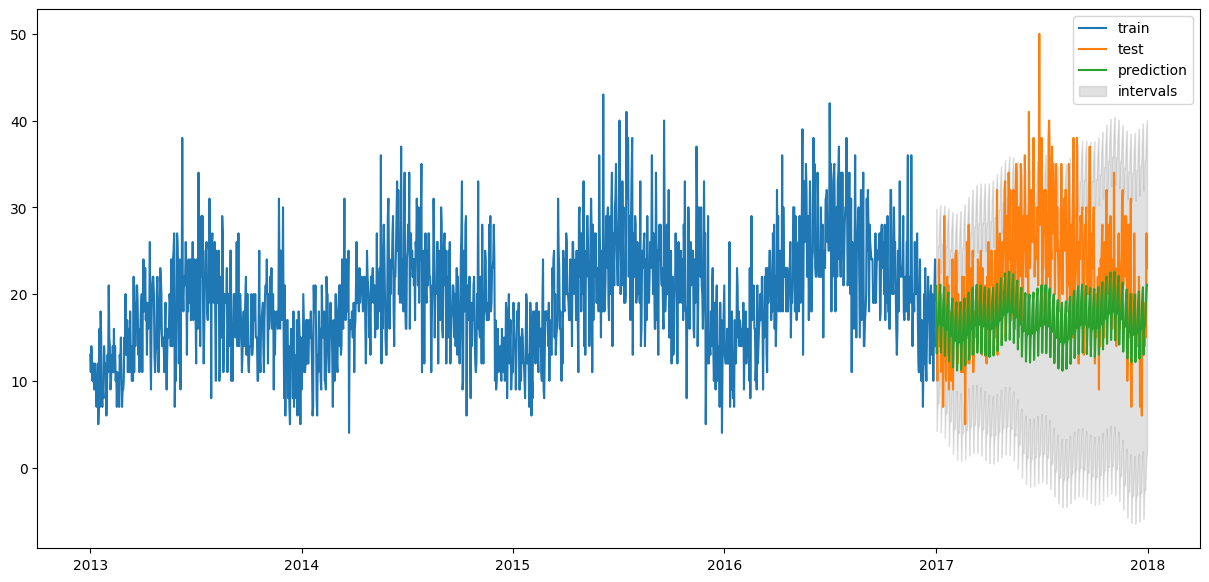

In [39]:
plot_results(data_train, data_test, tbats_forecast, plot_conf_int=True,
             left_bound=confidence_info['lower_bound'],
             right_bound=confidence_info['upper_bound'])

In [40]:
final_table = add_method_comparison('TBATS model', data_test, tbats_forecast, compare_table)

In [41]:
final_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760
3,Auto arima model,71.311533,6.669087,28.959919
4,ARIMA с exog,74.399898,6.831763,29.443817
5,Original SARIMAX,71.311533,6.669087,28.959919
6,SARIMAX с exog,24.477670,3.896864,19.522031
7,TBATS model,64.837759,6.335531,27.126884


### 8. ИТОГО

todo:
- Опишите, что вы сделали в этой работе, какие параметры моделей подбирали и как.
- Сравните модели между собой и проанализируйте результаты.
- Выберите лучшую модель.

Метрика MAPE, которую нужно достичь (достаточно правильной настройки гиперпараметров моделей), должна быть менее 20%.

In [42]:
final_table

,method,MSE,MAE,MAPE
0,Prophet,24.681247,4.032164,22.234031
1,Prophet + US holiday,25.021721,4.068054,22.477342
2,Prophet boxcox,24.350009,4.012787,21.834760
3,Auto arima model,71.311533,6.669087,28.959919
4,ARIMA с exog,74.399898,6.831763,29.443817
5,Original SARIMAX,71.311533,6.669087,28.959919
6,SARIMAX с exog,24.477670,3.896864,19.522031
7,TBATS model,64.837759,6.335531,27.126884


Анализ и сравнение моделей временных рядов
В этой работе мы провели анализ временного ряда, чтобы предсказать продажи товара. Были опробованы три модели: Prophet, ARIMA и SARIMAX.

1. Модель Prophet:

Была использована библиотека fbprophet.
Автоматически определяет тренд и сезонность, учитывает праздники США.
Гиперпараметры, которые были настроены:

2. Модель ARIMA:

Была использована библиотека pmdarima для автоматического подбора параметров.
Использовались сезонные параметры, периодом сезонности было 7 дней.
Подбирались параметры автоматически. Добавлены экзогенные переменные, представляющие собой синусоидальные функции, моделирующие годовую месячную и недельную сезонность,(sin365, cos365, sin365_2, cos365_2, sin7, cos7, sin30, cos30).

3. Модель SARIMAX:

Была использована библиотека statsmodels для создания модели с экзогенными переменными.
Использовались те же параметры ARIMA и сезонные параметры, что и в модели ARIMA.
Добавлены экзогенные переменные, представляющие собой синусоидальные функции, моделирующие годовую месячную и недельную сезонность,(sin365, cos365, sin365_2, cos365_2, sin7, cos7, sin30, cos30).

Лучшая модель SARIMAX с экзогенными переменными MAPE= 19.522031